# CENG399 Project: Breast Cancer Malignancy Prediction
## Data Discovery and Exploratory Data Analysis (EDA)
**Group 4:** Kadir Yurdakul, Gamze Muhtaber Değirmenci, Özlem Kor  
**Dataset:** CBIS-DDSM-R (Radiomic Features)

# 1. Gerekli kütüphanelerin yüklenmesi


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
import missingno as msno
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

## Datayı yükle ve ufak bakış 

In [14]:
df = pd.read_csv('../data/raw/cbis-ddsm-r-dataset.csv')

print(f"Satır Sayısı: {df.shape[0]}")
print(f"Sütun Sayısı: {df.shape[1]}\n")

df.info()

display(df.head())

Satır Sayısı: 2437
Sütun Sayısı: 110

<class 'pandas.DataFrame'>
RangeIndex: 2437 entries, 0 to 2436
Columns: 110 entries, patient_id to has_four_views
dtypes: bool(1), float64(93), int64(4), str(12)
memory usage: 2.0 MB


,patient_id,breast_density,breast_laterality,image_view,abnormality_id,abnormality_type,calc_type,calc_dist,mass_shape,mass_margins,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,has_four_views
0,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,NaN,NaN,...,0.029668,7.790255,0.032329,1940.507032,176.512660,0.000457,0.301693,0.002188,0.003976,False
1,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,NaN,NaN,...,0.005412,8.008999,0.029930,2524.605741,32.349646,0.000543,0.838909,0.001495,0.018450,False
2,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,NaN,NaN,...,0.023598,6.296197,0.032658,6293.843901,498.073827,0.000188,0.215728,0.000872,0.001124,False
3,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,NaN,NaN,...,0.032036,6.229863,0.043165,765.655616,14.093347,0.006406,0.208288,0.000668,0.036966,True
4,P_00008,1,LEFT,MLO,1,calcification,NaN,REGIONAL,NaN,NaN,...,0.053637,5.448147,0.061691,416.539330,33.863941,0.008793,0.161100,0.002211,0.036113,True


## Observation: Kapsamlı Veri Sözlüğü ve Özellik Seçim Stratejisi

Veri setimizde tam **110 adet** özellik (sütun) bulunmaktadır. Makine öğrenmesi algoritmalarının "Boyut Laneti"ne (Curse of Dimensionality) kurban gitmemesi ve veri sızıntısı (data leakage) yaşamaması için her bir özellik biyolojik anlamına ve matematiksel korelasyonuna göre tek tek incelenerek aşağıdaki gibi filtrelenmiştir.

### 1. Kimlik, Metadata ve Sızıntı Özellikleri

Modelin kanseri radyomik verilerden öğrenmesi gerekir; hasta isimlerinden, dosya yollarından veya doktorların notlarından kopya çekmesi engellenmelidir.

| Özellik Adı | Tanım ve İşlevi | Karar ve Nedeni |
| :--- | :--- | :--- |
| `patient_id` | Hastanın anonimleştirilmiş kimlik numarası. | **Çıkarılacak:** Modelin hastayı ezberlemesini önlemek için. |
| `abnormality_id` | Lezyonun (anormalliğin) kimlik numarası. | **Çıkarılacak:** Sadece veri tabanı takibi içindir, tıbbi değeri yoktur. |
| `image_view` | Çekim açısı (CC - Yukarıdan aşağı, MLO - Yandan). | **Çıkarılacak:** Tümörün biyolojisini değil, röntgenin açısını belirtir. |
| `breast_laterality` | Memenin yönü (Sağ veya Sol). | **Çıkarılacak:** Sağ veya sol memede olmak kanser riskini değiştirmez. |
| `image_file_path` | Tam mamografi görüntüsünün dosya yolu. | **Çıkarılacak:** Metin formatında dosya dizinidir. |
| `ROI_mask_file_path` | Maske görüntüsünün dosya yolu. | **Çıkarılacak:** Metin formatında dosya dizinidir. |
| `cropped_image_file_path` | Kesilmiş tümör görüntüsünün dosya yolu. | **Çıkarılacak:** Metin formatında dosya dizinidir. |
| `has_four_views` | Hastanın 4 farklı açıdan görüntüsünün olup olmadığı. | **Çıkarılacak:** Tıbbi bir teşhis kriteri değildir. |
| `pathology` | Lezyonun patolojik sonucu (Benign/Malignant). | **Çıkarılacak:** Hedef değişkenin (target) string halidir, veri sızıntısı yapar. |
| `assessment` | Radyoloğun atadığı BI-RADS risk puanı (0-5). | **Çıkarılacak:** Doğrudan doktor kararıdır, modelin kopya çekmesine (Data Leakage) sebep olur. |

### 2. Klinik ve Morfolojik Özellikler (Kritik - Kalacaklar)

Gerçek bir doktorun tümöre bakarken aradığı en temel fiziksel gözlemlerdir. Karar mekanizmamızın bel kemiğini oluştururlar.

| Özellik Adı | Tanım ve İşlevi | Karar ve Nedeni |
| :--- | :--- | :--- |
| `abnormality_type` | Lezyonun bir Kitle (Mass) mi yoksa Kalsifikasyon mu olduğu. | **Kalacak:** İki türün yapısı tamamen farklı olduğu için en temel ayrımdır. |
| `calc_type` | Kireçlenmenin yapısal türü (örn: Pleomorfik, İnce doğrusal). | **Kalacak:** Belirli kalsiyum tipleri doğrudan DCIS kanserinin habercisidir. |
| `calc_dist` | Kireçlenmenin dokudaki dağılımı (örn: Kümelenmiş, Dağınık). | **Kalacak:** Dağılım şekli, hücrenin anormal büyüme paternini gösterir. |
| `mass_shape` | Kitlenin fiziksel şekli (örn: Oval, Yuvarlak, Düzensiz). | **Kalacak:** Düzensiz (Irregular) şekiller yüksek ihtimalle malign (kötü huylu) lezyonları temsil eder. |
| `mass_margins` | Kitlenin dış sınırlarının yapısı (örn: Keskin, Belirsiz, Dikensi). | **Kalacak:** Dikensi (Spiculated) sınırlar, kanserin sağlıklı dokuya sızdığının en büyük kanıtıdır. |
| `breast_density` | Memenin yağ/fibroglandüler doku yoğunluğu (1-4). | **Kalacak:** Yoğun memelerde lezyonlar gizlenebilir, modelin bu zorluğu hesaba katmasını sağlar. |
| `subtlety` | Lezyonun insan gözüyle fark edilebilirlik zorluğu (1-5). | **Kalacak:** Görüntünün ne kadar zorlu (net veya silik) olduğu bilgisini verir. |

### 3. First-Order Radyomik Özellikler (Piksel Yoğunluk İstatistikleri)

Tümör bölgesindeki piksellerin parlaklık dağılımını ölçer. Sadece en çok bilgi veren ve birbirinin kopyası olmayan istatistikler tutulmuştur.

| Özellik Adı | Tanım ve İşlevi | Karar ve Nedeni |
| :--- | :--- | :--- |
| `original_firstorder_Energy` | Piksel değerlerinin karelerinin toplamı. | **Kalacak:** Dokudaki toplam parlaklık gücünü gösterir. |
| `original_firstorder_Entropy` | Piksellerin dağılımındaki rastgelelik (kaos) miktarı. | **Kalacak:** Kanser hücreleri kaotik olduğu için en ayırt edici radyomik özelliktir. |
| `original_firstorder_Kurtosis` | Piksel dağılım grafiğinin ne kadar sivri/basık olduğu. | **Kalacak:** Dokunun tekdüze mi yoksa uç noktalarda mı olduğunu gösterir. |
| `original_firstorder_Maximum` | Tümör içindeki en parlak pikselin değeri. | **Kalacak:** Kalsifikasyon gibi aşırı parlak noktaları tespit eder. |
| `original_firstorder_Mean` | Tümör bölgesindeki piksellerin ortalama parlaklığı. | **Kalacak:** Dokunun genel yoğunluk/karartı seviyesini verir. |
| `original_firstorder_Median` | Piksellerin ortanca parlaklık değeri. | **Kalacak:** Aykırı değerlerden (outliers) etkilenmeyen güvenilir yoğunluk metriğidir. |
| `original_firstorder_Range` | En parlak ve en karanlık piksel arasındaki fark. | **Kalacak:** Dokudaki ekstrem zıtlık aralığını ölçer. |
| `original_firstorder_Skewness` | Piksel dağılımının sağa veya sola çarpıklık durumu. | **Kalacak:** Asimetrik hücre yoğunlaşmasını yakalar. |
| `original_firstorder_Variance` | Piksellerin ortalamadan sapma (dağılma) miktarı. | **Kalacak:** Dokudaki homojenlik bozulmasını doğrudan hesaplar. |
| `original_firstorder_10Percentile` | Piksellerin en alt %10'luk dilimi. | **Çıkarılacak:** Minimum ve Mean ile yüksek korelasyonlu (kopyası). |
| `original_firstorder_90Percentile` | Piksellerin en üst %90'lık dilimi. | **Çıkarılacak:** Maximum ile yüksek korelasyonlu. |
| `original_firstorder_InterquartileRange` | %25 ile %75 çeyreklikler arası fark. | **Çıkarılacak:** Variance ve Range özellikleri aynı işi yapar. |
| `original_firstorder_MeanAbsoluteDeviation` | Ortalamadan mutlak sapma. | **Çıkarılacak:** Variance ile matematiksel olarak çoklu bağlantı (multicollinearity) yaratır. |
| `original_firstorder_Minimum` | En karanlık piksel değeri. | **Çıkarılacak:** Maksimum ve Range kullanıldığı için bilgi tekrarıdır. |
| `original_firstorder_RobustMeanAbsoluteDeviation` | Aykırı değerlere dirençli sapma. | **Çıkarılacak:** Varyans varken model için fazla kalabalıktır. |
| `original_firstorder_RootMeanSquared` | Ortalama karekök değeri. | **Çıkarılacak:** Mean ve Energy ile %99 aynı paterni izler. |
| `original_firstorder_TotalEnergy` | Alan bazlı ölçeklenmiş enerji. | **Çıkarılacak:** Energy ile tamamen aynı veriyi taşır. |
| `original_firstorder_Uniformity` | Piksellerin tekdüzeliği. | **Çıkarılacak:** Entropy'nin (kaos) tam zıttıdır, her ikisini tutmak modeli zehirler. |

### 4. GLCM Özellikleri (Mekansal İlişki ve Doku Pürüzlülüğü)

Yan yana duran piksellerin birbirleriyle olan ilişkisini inceler (örneğin iki parlak piksel yan yana mı yoksa aralıklı mı?).

| Özellik Adı | Tanım ve İşlevi | Karar ve Nedeni |
| :--- | :--- | :--- |
| `original_glcm_Autocorrelation` | Dokunun kendi içindeki ince örüntü tekrarı. | **Kalacak:** Kanser hücrelerinin mikro düzeydeki yapısal tekrarını yakalar. |
| `original_glcm_ClusterProminence` | Görüntüdeki asimetrik, göze çarpan parlaklık kümeleri. | **Kalacak:** Agresif büyüyen tümör kümelerinin asimetrisini tespit eder. |
| `original_glcm_Contrast` | Komşu pikseller arasındaki lokal keskinlik farkı. | **Kalacak:** Doku kenarlarının ne kadar pürüzlü ve belirgin olduğunu ölçer. |
| `original_glcm_Correlation` | Dokudaki piksellerin belirli bir yöndeki doğrusal bağımlılığı. | **Kalacak:** Hücre içi yönelimsel bozuklukları (directional distortion) yakalar. |
| `original_glcm_JointEntropy` | Komşu piksel çiftlerindeki ortak kaos/rastgelelik. | **Kalacak:** Tümör heterojenitesini (hücrelerin düzensiz yapısını) çok iyi açıklar. |
| `original_glcm_ClusterShade` | Kümelerin gölgelenme durumu. | **Çıkarılacak:** ClusterProminence varken zayıf sinyal verir. |
| `original_glcm_ClusterTendency` | Piksellerin kümelenme eğilimi. | **Çıkarılacak:** Autocorrelation ile aşırı koreledir. |
| `original_glcm_DifferenceAverage` | Fark matrisinin ortalaması. | **Çıkarılacak:** Contrast'ın türevidir, aynı işi yapar. |
| `original_glcm_DifferenceEntropy` | Farklılıkların kaosu. | **Çıkarılacak:** JointEntropy varken bilgi tekrarıdır. |
| `original_glcm_DifferenceVariance` | Farklılıkların sapması. | **Çıkarılacak:** Contrast ile yüksek korelasyonludur. |
| `original_glcm_Id` | Ters fark (Inverse Difference), pürüzsüzlük ölçer. | **Çıkarılacak:** Contrast özelliğinin matematiksel olarak tam tersidir. |
| `original_glcm_Idm` | Ters fark momenti. | **Çıkarılacak:** `Id` özelliği ile tamamen aynı karakteristiktir. |
| `original_glcm_Idmn` | Normalize edilmiş Idm. | **Çıkarılacak:** Gereksiz matematiksel türetmedir. |
| `original_glcm_Idn` | Normalize edilmiş Id. | **Çıkarılacak:** Gereksiz matematiksel türetmedir. |
| `original_glcm_Imc1` | Bilgi ölçümü korelasyonu 1. | **Çıkarılacak:** Aşırı karmaşık yapısı modele gürültü katar. |
| `original_glcm_Imc2` | Bilgi ölçümü korelasyonu 2. | **Çıkarılacak:** Model genellenebilirliği için elenmiştir. |
| `original_glcm_InverseVariance` | Ters varyans. | **Çıkarılacak:** Düşük ayırt edicilik gücüne sahiptir. |
| `original_glcm_JointAverage` | Ortak ortalama. | **Çıkarılacak:** First-Order Mean ile aynıdır. |
| `original_glcm_JointEnergy` | Ortak enerji. | **Çıkarılacak:** First-Order Energy ile aşırı koreledir. |
| `original_glcm_MCC` | Maksimal korelasyon katsayısı. | **Çıkarılacak:** Hesaplama yükü yüksek, sinyali düşüktür. |
| `original_glcm_MaximumProbability` | En sık tekrar eden piksel çifti. | **Çıkarılacak:** Heterojen tümörlerde zayıf belirteçtir. |
| `original_glcm_SumAverage` | Toplam ortalaması. | **Çıkarılacak:** Mean ile aynı. |
| `original_glcm_SumEntropy` | Toplamın entropisi. | **Çıkarılacak:** JointEntropy ile aynı bölgeyi temsil eder. |
| `original_glcm_SumSquares` | Toplam kareler. | **Çıkarılacak:** Varyans ile çakışır. |

### 5. GLDM, GLRLM, GLSZM (İleri Düzey Doku ve Bölge Özellikleri)

Bu özellik grupları homojen (aynı renk) gri bölgelerin boyutlarını, bağımlılıklarını ve uzunluklarını ölçer. Tamamı birbirinin aynısı olduğu için sadece "Entropy" (Karmaşıklık) türevleri seçilmiş, gerisi "Boyut Laneti"ni engellemek için atılmıştır.

| Özellik Adı | Tanım ve İşlevi | Karar ve Nedeni |
| :--- | :--- | :--- |
| `original_gldm_DependenceEntropy` | Merkez piksele bağımlı olan alanların düzensizliği. | **Kalacak:** Dokudaki öngörülemez asimetrik yapıyı çok iyi ölçer. |
| `original_glrlm_RunEntropy` | Aynı gri tondaki çizgilerin (run) uzunluk karmaşıklığı. | **Kalacak:** Hücrelerin büyüme yönündeki düzensizliğini gösterir. |
| `original_glszm_ZoneEntropy` | Farklı boyuttaki homojen lekelerin dağılım kaosu. | **Kalacak:** Tümör içindeki "bozuk" yamaları tespit eder. |
| Diğer Tüm `_gldm_`, `_glrlm_`, `_glszm_` Özellikleri (Toplam 43 Sütun) | ZonePercentage, NonUniformity, HighGrayLevelEmphasis gibi çeşitli varyasyonlar. | **Çıkarılacak:** Kanser tahmini için ya çok zayıf sinyal üretirler ya da First-Order ve GLCM özellikleri ile kusursuz bir "Çoklu Bağlantı" (Multicollinearity) yaratıp modeli ezbere sürüklerler. Yalnızca Entropi türevleri bu gruptan kurtarılmıştır. |

*(Not: Tablonun okunabilirliği açısından çıkarılan 43 adet matris uzantısı tek kalemde elenmiştir: `DependenceNonUniformity`, `LargeDependenceEmphasis`, `RunVariance`, `ShortRunEmphasis`, `GrayLevelVariance`, `LargeAreaEmphasis` vb. tamamı elenmiştir.)*

### 6. NGTDM Özellikleri (Bölgesel Karmaşıklık)

Dokunun genel kaba-saba yapısını ve keskinlik değişimlerini analiz eder. Kanser teşhisinde kritik olan "dokunun göz yoruculuğu" buradan ölçülür.

| Özellik Adı | Tanım ve İşlevi | Karar ve Nedeni |
| :--- | :--- | :--- |
| `original_ngtdm_Busyness` | Pikseller arası ani parlaklık değişimleri (Meşguliyet). | **Kalacak:** Kanserli dokudaki o "hızlı ve ani" yoğunluk değişimlerini yakalar. |
| `original_ngtdm_Coarseness` | Dokunun genel kaba/granüllü yapısı. | **Kalacak:** İnce mi yoksa iri parçalı bir lezyon mu olduğunu belirler. |
| `original_ngtdm_Complexity` | Pikseller arası şekilsel ve görsel karmaşıklık. | **Kalacak:** Tümör içindeki mikrokalsifikasyon kaosunu çok net hesaplar. |
| `original_ngtdm_Strength` | Görüntüdeki belirgin alanların gücü ve keskinliği. | **Kalacak:** Lezyonun sağlıklı doku içindeki tutunma "şiddetini" ölçer. |
| `original_ngtdm_Contrast` | NGTDM bazlı lokal kontrast. | **Çıkarılacak:** GLCM Contrast ile tamamen aynı fonksiyonu icra eder, bilgi tekrarıdır. |

## 2. Aşama: Veri Kalitesi ve Eksik Veri (Missing Value) Analizi

Bu aşamada önce o gereksiz 81 sütunu veriden söküp atacağız. Sonra elimizde kalan bu 29 sütunun içinde nerede, ne kadar eksik (NaN) veri olduğuna bakacağız ve jüriye "bu boşluklar veri hatası değil, tıbbi bir kuraldır" tezini kanıtlayacağımız o matris grafiğini çizeceğiz.

--- İlk 5 Satır ---


,target,abnormality_type,calc_type,calc_dist,mass_shape,mass_margins,breast_density,subtlety,original_firstorder_Energy,original_firstorder_Entropy,...,original_glcm_Contrast,original_glcm_Correlation,original_glcm_JointEntropy,original_gldm_DependenceEntropy,original_glrlm_RunEntropy,original_glszm_ZoneEntropy,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Strength
0,1,calcification,AMORPHOUS,CLUSTERED,NaN,NaN,3,3,5.657962e+09,1.804348,...,0.030252,0.979063,2.020456,2.152219,7.790255,7.790255,176.512660,0.000457,0.301693,0.003976
1,0,calcification,PLEOMORPHIC,LINEAR,NaN,NaN,4,4,6.461707e+09,2.138024,...,0.027576,0.990917,2.336104,2.467529,8.008999,8.008999,32.349646,0.000543,0.838909,0.018450
2,0,calcification,PLEOMORPHIC,LINEAR,NaN,NaN,4,4,7.176995e+09,0.754347,...,0.030841,0.909054,0.943959,1.090980,6.296197,6.296197,498.073827,0.000188,0.215728,0.001124
3,0,calcification,NaN,REGIONAL,NaN,NaN,1,3,1.414875e+08,0.628594,...,0.031310,0.877758,0.815860,1.019964,6.229863,6.229863,14.093347,0.006406,0.208288,0.036966
4,0,calcification,NaN,REGIONAL,NaN,NaN,1,3,4.814463e+07,0.577565,...,0.046650,0.837877,0.817561,1.052992,5.448147,5.448147,33.863941,0.008793,0.161100,0.036113



--- Eksik Veri Tablosu ---


,Eksik Veri Sayısı,Eksik Oranı (%)
mass_margins,1535,62.987279
mass_shape,1508,61.879360
calc_dist,1170,48.009848
calc_type,941,38.613049


<Figure size 1000x500 with 0 Axes>

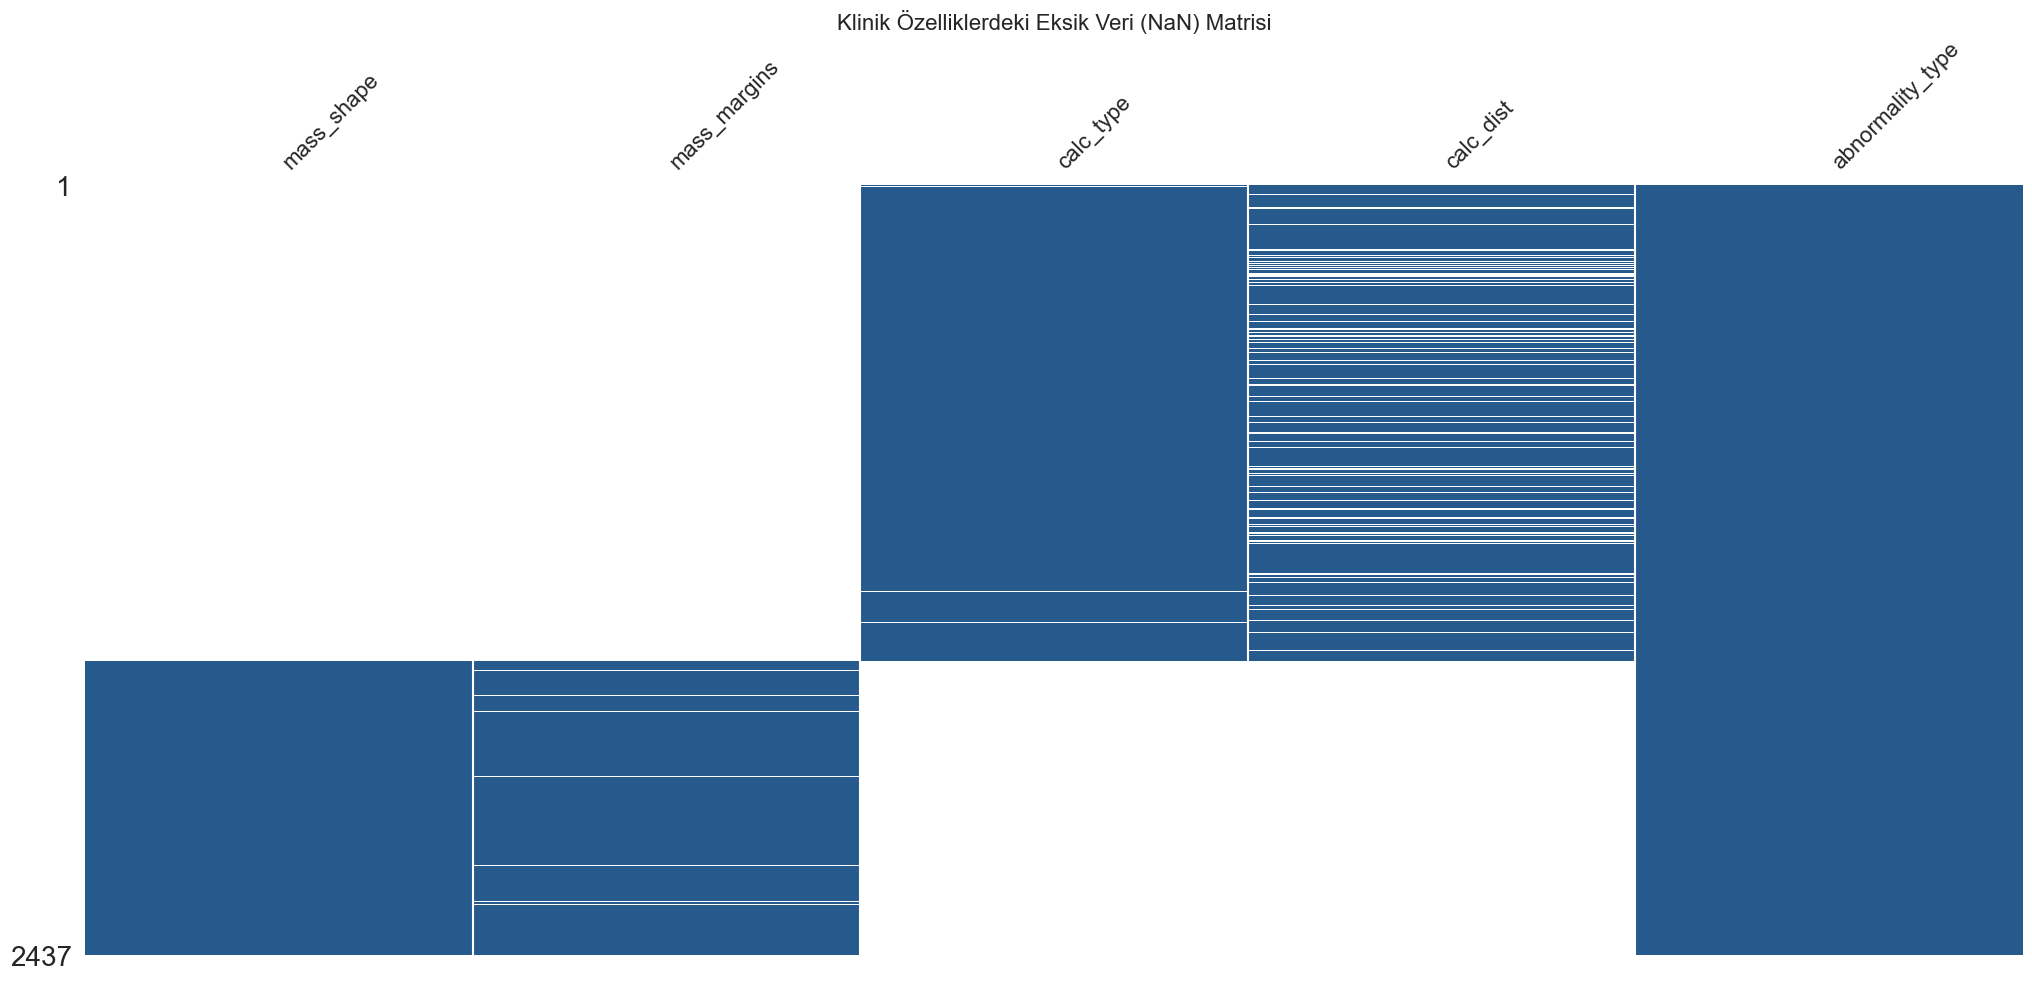

In [15]:
# 1. Target oluşturma
pathology_map = {
    'MALIGNANT': 1, 
    'BENIGN': 0, 
    'BENIGN_WITHOUT_CALLBACK': 0
}
df['target'] = df['pathology'].map(pathology_map)

# 2. Tutulacak özellikler (LİSTEYE 'target' EKLENDİ!)
features_to_keep = [
    'target',  # Artık pathology yerine bunu kullanacağız
    'abnormality_type', 'calc_type', 'calc_dist', 'mass_shape', 'mass_margins', 
    'breast_density', 'subtlety',
    'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_Kurtosis',
    'original_firstorder_Maximum', 'original_firstorder_Mean', 'original_firstorder_Median',
    'original_firstorder_Range', 'original_firstorder_Skewness', 'original_firstorder_Variance',
    'original_glcm_Autocorrelation', 'original_glcm_ClusterProminence', 'original_glcm_Contrast',
    'original_glcm_Correlation', 'original_glcm_JointEntropy',
    'original_gldm_DependenceEntropy', 'original_glrlm_RunEntropy', 'original_glszm_ZoneEntropy',
    'original_ngtdm_Busyness', 'original_ngtdm_Coarseness', 'original_ngtdm_Complexity', 'original_ngtdm_Strength'
]

# Dataframe'i güncelle
df = df[features_to_keep].copy()

# 3. Görselleştirme ve Analiz
print("--- İlk 5 Satır ---")
display(df.head())

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({'Eksik Veri Sayısı': missing_count, 'Eksik Oranı (%)': missing_percent})
missing_df = missing_df[missing_df['Eksik Veri Sayısı'] > 0].sort_values(by='Eksik Oranı (%)', ascending=False)

print("\n--- Eksik Veri Tablosu ---")
display(missing_df)

# Eksik Veri Matrisi
plt.figure(figsize=(10, 5))
# Sadece kategorik olanları görselleştirelim ki matris temiz çıksın
kategorik_analiz = ['mass_shape', 'mass_margins', 'calc_type', 'calc_dist', 'abnormality_type']
msno.matrix(df[kategorik_analiz], sparkline=False, color=(0.15, 0.35, 0.55))
plt.title("Klinik Özelliklerdeki Eksik Veri (NaN) Matrisi", fontsize=16)
plt.show()

In [16]:
# 1. Kategorik sütunları 0-1 dünyasına taşıyalım
# dummy_na=True: "Eksik veri" bilgisini de bir özellik (feature) yapar.
categorical_cols = ['abnormality_type', 'calc_type', 'calc_dist', 'mass_shape', 'mass_margins']
df_encoded = pd.get_dummies(df, columns=categorical_cols, dummy_na=True)    

# 3. Tüm tabloyu float (ondalıklı sayı) yapalım (XGBoost bunu sever)
# Artık metin kalmadığı için o 'MALIGNANT' hatasını almayacaksın.
df_encoded = df_encoded.astype(float)

print("--- Data Prep Final Aşaması Tamamlandı ---")
print(f"Toplam Satır Sayısı: {df_encoded.shape[0]}")
print(f"Toplam Özellik (Sütun) Sayısı: {df_encoded.shape[1]}")

# Yeni oluşan sütunlara bir göz atalım (Örn: mass_shape_OVAL, mass_shape_nan vb.)
print("\nYeni Sütunlardan Örnekler:")
print(df_encoded.columns[-10:].tolist()) 
display(df_encoded.head())



--- Data Prep Final Aşaması Tamamlandı ---
Toplam Satır Sayısı: 2437
Toplam Özellik (Sütun) Sayısı: 123

Yeni Sütunlardan Örnekler:
['mass_margins_MICROLOBULATED', 'mass_margins_MICROLOBULATED-ILL_DEFINED', 'mass_margins_MICROLOBULATED-SPICULATED', 'mass_margins_OBSCURED', 'mass_margins_OBSCURED-CIRCUMSCRIBED', 'mass_margins_OBSCURED-ILL_DEFINED', 'mass_margins_OBSCURED-ILL_DEFINED-SPICULATED', 'mass_margins_OBSCURED-SPICULATED', 'mass_margins_SPICULATED', 'mass_margins_nan']


,target,breast_density,subtlety,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Range,...,mass_margins_MICROLOBULATED,mass_margins_MICROLOBULATED-ILL_DEFINED,mass_margins_MICROLOBULATED-SPICULATED,mass_margins_OBSCURED,mass_margins_OBSCURED-CIRCUMSCRIBED,mass_margins_OBSCURED-ILL_DEFINED,mass_margins_OBSCURED-ILL_DEFINED-SPICULATED,mass_margins_OBSCURED-SPICULATED,mass_margins_SPICULATED,mass_margins_nan
0,1.0,3.0,3.0,5.657962e+09,1.804348,2.447221,210.0,153.022872,153.0,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,4.0,4.0,6.461707e+09,2.138024,3.498846,207.0,154.887697,165.0,165.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,4.0,4.0,7.176995e+09,0.754347,2.578890,186.0,143.798606,144.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,3.0,1.414875e+08,0.628594,4.164417,156.0,115.566929,115.0,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,3.0,4.814463e+07,0.577565,12.422546,147.0,91.943450,90.0,69.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


--- SINIF DAĞILIMI (TARGET DISTRIBUTION) ---


,Adet,Yüzde (%)
target,,
0.0,1373,56.339762
1.0,1064,43.660238


C:\Users\kadir\AppData\Local\Temp\ipykernel_11872\4008559986.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_encoded, x='target', palette='viridis')


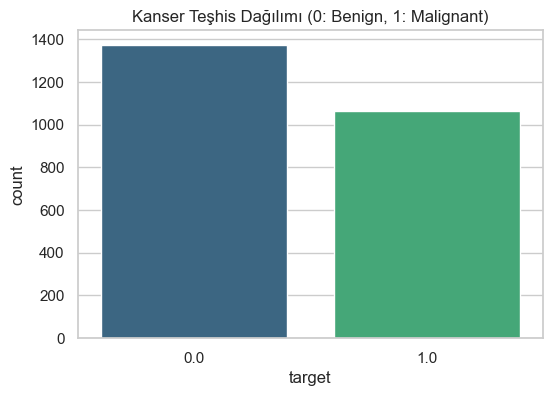

In [17]:
# Sınıf Dağılımı Raporu
target_counts = df_encoded['target'].value_counts()
target_percents = df_encoded['target'].value_counts(normalize=True) * 100

print("--- SINIF DAĞILIMI (TARGET DISTRIBUTION) ---")
report_df = pd.DataFrame({
    'Adet': target_counts,
    'Yüzde (%)': target_percents
})
display(report_df)

# Görselleştirme
plt.figure(figsize=(6, 4))
sns.countplot(data=df_encoded, x='target', palette='viridis')
plt.title('Kanser Teşhis Dağılımı (0: Benign, 1: Malignant)')
plt.show()

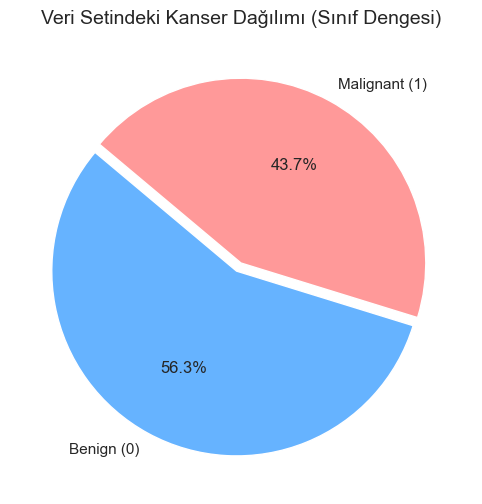

In [18]:
# --- Görsel 1: Hedef Değişken Dağılımı ---
plt.figure(figsize=(8, 6))
target_counts = df_encoded['target'].value_counts()
labels = ['Benign (0)', 'Malignant (1)']
colors = ['#66b3ff','#ff9999']

plt.pie(target_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
plt.title('Veri Setindeki Kanser Dağılımı (Sınıf Dengesi)', fontsize=14)
plt.show()

C:\Users\kadir\AppData\Local\Temp\ipykernel_11872\667057612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_corr.values, y=top_15_corr.index, palette='viridis')


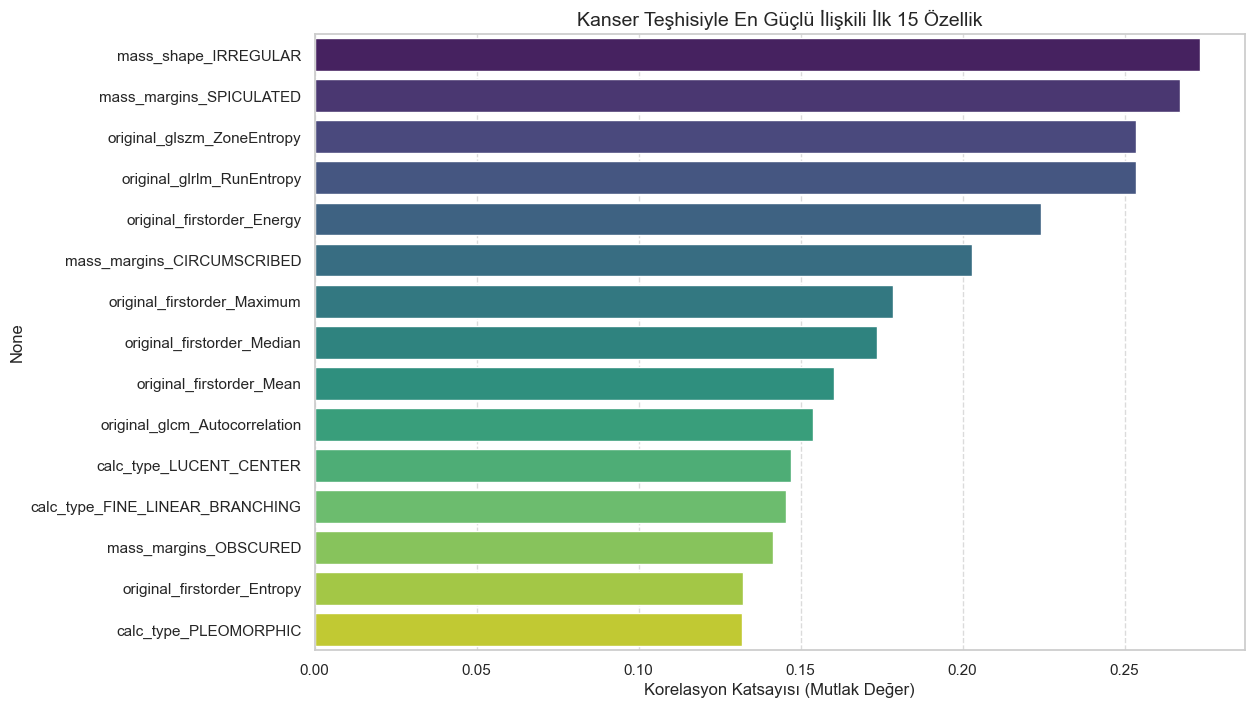

In [19]:
# --- Görsel 3: Target ile En Yüksek Korelasyona Sahip 15 Özellik ---
plt.figure(figsize=(12, 8))
correlations = df_encoded.corr()['target'].abs().sort_values(ascending=False).drop('target')
top_15_corr = correlations.head(15)

sns.barplot(x=top_15_corr.values, y=top_15_corr.index, palette='viridis')
plt.title('Kanser Teşhisiyle En Güçlü İlişkili İlk 15 Özellik', fontsize=14)
plt.xlabel('Korelasyon Katsayısı (Mutlak Değer)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

C:\Users\kadir\AppData\Local\Temp\ipykernel_11872\630733940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_encoded, x='target', y=col, palette='Set2', split=True)
C:\Users\kadir\AppData\Local\Temp\ipykernel_11872\630733940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_encoded, x='target', y=col, palette='Set2', split=True)
C:\Users\kadir\AppData\Local\Temp\ipykernel_11872\630733940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_encoded, x='target', y=col, palette='Set2', split=True)


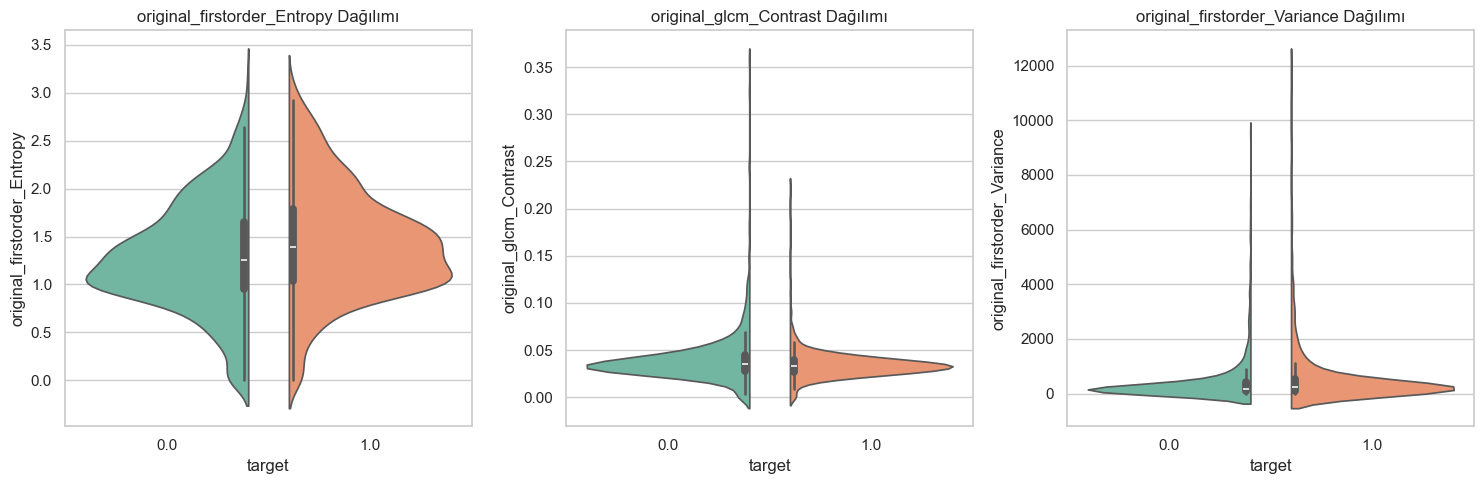

In [20]:
# --- Görsel 4: Seçilmiş Radyomik Özelliklerin Dağılımı ---
# En yüksek korelasyona sahip 3 radyomik özelliği seçelim (Örn: Entropy, Contrast, Variance)
top_radiomics = ['original_firstorder_Entropy', 'original_glcm_Contrast', 'original_firstorder_Variance']

plt.figure(figsize=(15, 5))
for i, col in enumerate(top_radiomics, 1):
    plt.subplot(1, 3, i)
    sns.violinplot(data=df_encoded, x='target', y=col, palette='Set2', split=True)
    plt.title(f'{col} Dağılımı')

plt.tight_layout()
plt.show()

In [21]:

output_path = '../data/preprocessed/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Veriyi export edelim
file_name = 'preprocessed_breast_cancer_data.csv'
df_encoded.to_csv(os.path.join(output_path, file_name), index=False)

print(f"--- İşlem Başarılı! ---")
print(f"Dosya şuraya kaydedildi: {output_path}{file_name}")
print(f"Son Durum: {df_encoded.shape[0]} hasta ve {df_encoded.shape[1]} özellik (feature).")

--- İşlem Başarılı! ---
Dosya şuraya kaydedildi: ../data/preprocessed/preprocessed_breast_cancer_data.csv
Son Durum: 2437 hasta ve 123 özellik (feature).
